# Walmart Demand Forecasting

## Milestone 2.3 — Baseline and Machine Learning Models

This notebook trains and evaluates demand forecasting models using the engineered Walmart feature dataset.

The modeling workflow includes:

- Loading the engineered feature dataset
- Creating a time-based train/test split
- Establishing a baseline forecast
- Training machine learning models
- Evaluating model performance
- Comparing results and selecting the best model

In [1]:
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

data_path = Path("../data/processed/walmart_features.pkl")

model_df = pd.read_pickle(data_path)

print(model_df.shape)

model_df.head()

(4748523, 30)


,date,store_id,item_id,units_sold,lag_1,lag_7,lag_30,rolling_avg_7,rolling_avg_28,sales_change_1,...,is_event,snap_active,temperature_max,temperature_min,precipitation,snowfall,wind_speed_max,cpi,unemployment_rate,federal_funds_rate
30,2011-02-28,CA_1,FOODS_1_001,0,2.0,0.0,3.0,2.000000,1.428571,2.0,...,0,0,16.8,0.9,0.0,0.0,12.1,221.898,9.0,0.16
31,2011-03-01,CA_1,FOODS_1_001,2,0.0,2.0,0.0,2.000000,1.428571,-2.0,...,0,1,16.3,3.0,0.0,0.0,12.5,223.046,9.0,0.14
32,2011-03-02,CA_1,FOODS_1_001,1,2.0,2.0,0.0,2.000000,1.464286,0.0,...,0,1,15.1,4.7,0.4,0.0,7.6,223.046,9.0,0.14
33,2011-03-03,CA_1,FOODS_1_001,7,1.0,2.0,1.0,1.857143,1.357143,-1.0,...,0,1,18.7,9.9,0.0,0.0,11.3,223.046,9.0,0.14
34,2011-03-04,CA_1,FOODS_1_001,1,7.0,4.0,4.0,2.571429,1.535714,3.0,...,0,1,23.1,6.9,0.0,0.0,8.0,223.046,9.0,0.14


## Time-Based Train/Test Split

Because this is a forecasting problem, the dataset must be split chronologically rather than randomly.

Earlier observations will be used for training, while the most recent observations will be reserved for testing. This prevents future information from leaking into the training data and better represents a real-world forecasting scenario.

In [3]:
# Make sure date is datetime
model_df["date"] = pd.to_datetime(model_df["date"])

# Check the available date range
print("Start date:", model_df["date"].min())
print("End date:", model_df["date"].max())
print("Total unique dates:", model_df["date"].nunique())

Start date: 2011-02-28 00:00:00
End date: 2016-05-22 00:00:00
Total unique dates: 1911


### Forecast Horizon

The final 28 days of the dataset are reserved as the test period.

This creates a realistic forecasting setup where the model is trained only on historical observations and evaluated on future observations it has not seen during training.

In [4]:
# Define a 28-day forecasting horizon
forecast_horizon = 28

# Determine the test-period starting date
max_date = model_df["date"].max()
test_start_date = max_date - pd.Timedelta(days=forecast_horizon - 1)

# Chronological split
train_df = model_df[
    model_df["date"] < test_start_date
].copy()

test_df = model_df[
    model_df["date"] >= test_start_date
].copy()

print("Train start:", train_df["date"].min())
print("Train end:", train_df["date"].max())

print("\nTest start:", test_df["date"].min())
print("Test end:", test_df["date"].max())

print("\nTraining rows:", f"{len(train_df):,}")
print("Testing rows:", f"{len(test_df):,}")

Train start: 2011-02-28 00:00:00
Train end: 2016-04-24 00:00:00

Test start: 2016-04-25 00:00:00
Test end: 2016-05-22 00:00:00

Training rows: 4,663,151
Testing rows: 85,372


## Baseline Forecast

Before training machine learning models, a simple baseline forecast is established.

The baseline uses sales from 28 days earlier (`lag_28`) as the prediction for the current day. This represents a seasonal naive forecast and provides a benchmark that more advanced models should outperform.

In [5]:
# Create baseline predictions
baseline_predictions = test_df["rolling_avg_28"]

# Actual demand
actual = test_df["units_sold"]

print("Predictions:", len(baseline_predictions))
print("Actual values:", len(actual))

Predictions: 85372
Actual values: 85372


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_mae = mean_absolute_error(
    actual,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        actual,
        baseline_predictions
    )
)

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline MAE: 1.1288
Baseline RMSE: 2.1931


## Machine Learning Dataset

The target variable is `units_sold`.

Historical demand, pricing, calendar, event, weather, and economic variables are used as predictive features.

Identifier and date columns are excluded from the initial model because they are not directly numeric model inputs.

In [7]:
feature_columns = [
    # Historical demand
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_avg_7",
    "rolling_avg_28",
    "sales_change_1",
    "sales_change_7_28",

    # Pricing
    "sell_price",
    "price_lag_1",
    "price_change_1",
    "price_pct_change_1",

    # Calendar
    "day_of_week",
    "month",
    "year",
    "day_of_month",
    "is_weekend",

    # Events / SNAP
    "is_event",
    "snap_active",

    # Weather
    "temperature_max",
    "temperature_min",
    "precipitation",
    "snowfall",
    "wind_speed_max",

    # Economic
    "cpi",
    "unemployment_rate",
    "federal_funds_rate"
]

target = "units_sold"

In [8]:
X_train = train_df[feature_columns]
y_train = train_df[target]

X_test = test_df[feature_columns]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4663151, 26)
y_train: (4663151,)

X_test: (85372, 26)
y_test: (85372,)


## Linear Regression Model

A linear regression model is trained as the first machine-learning benchmark.

The model uses the engineered demand, pricing, calendar, event, weather, and economic features to predict daily units sold.

Its performance will be compared against the baseline forecast.

In [9]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

In [10]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")

print()

print(f"Linear Regression MAE: {linear_mae:.4f}")
print(f"Linear Regression RMSE: {linear_rmse:.4f}")

Baseline MAE: 1.1288
Baseline RMSE: 2.1931

Linear Regression MAE: 1.1253
Linear Regression RMSE: 2.1310


## Gradient Boosting Model

A histogram-based gradient boosting regression model is trained to capture nonlinear relationships between demand and the engineered features.

Unlike linear regression, gradient boosting can model more complex interactions among historical sales, pricing, calendar, weather, event, and economic variables.

In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

hgb_model.fit(
    X_train,
    y_train
)

hgb_predictions = hgb_model.predict(X_test)

In [12]:
hgb_mae = mean_absolute_error(
    y_test,
    hgb_predictions
)

hgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        hgb_predictions
    )
)

print(f"Baseline MAE:          {baseline_mae:.4f}")
print(f"Baseline RMSE:         {baseline_rmse:.4f}")

print()

print(f"Linear Regression MAE: {linear_mae:.4f}")
print(f"Linear Regression RMSE:{linear_rmse:.4f}")

print()

print(f"Gradient Boosting MAE: {hgb_mae:.4f}")
print(f"Gradient Boosting RMSE:{hgb_rmse:.4f}")

Baseline MAE:          1.1288
Baseline RMSE:         2.1931

Linear Regression MAE: 1.1253
Linear Regression RMSE:2.1310

Gradient Boosting MAE: 1.0882
Gradient Boosting RMSE:2.0327


## Model Comparison

The forecasting models are compared using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

Lower values indicate better forecasting performance.

In [13]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        hgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        hgb_rmse
    ]
})

results = results.sort_values("RMSE").reset_index(drop=True)

results

,Model,MAE,RMSE
0,Gradient Boosting,1.088202,2.032651
1,Linear Regression,1.125331,2.130962
2,Baseline,1.128785,2.193091


## Best Model Performance

Gradient Boosting produced the lowest MAE and RMSE, making it the best-performing forecasting model tested.

The following calculation measures how much the model improved over the baseline forecast.

In [14]:
mae_improvement = (
    (baseline_mae - hgb_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - hgb_rmse)
    / baseline_rmse
) * 100

print(f"MAE improvement over baseline: {mae_improvement:.2f}%")
print(f"RMSE improvement over baseline: {rmse_improvement:.2f}%")

MAE improvement over baseline: 3.60%
RMSE improvement over baseline: 7.32%


## Actual vs. Predicted Demand

The best-performing Gradient Boosting model is evaluated by comparing its predicted demand against the actual observed demand in the test period.

In [15]:
prediction_results = test_df[
    ["date", "store_id", "item_id", "units_sold"]
].copy()

prediction_results["predicted_units_sold"] = hgb_predictions

prediction_results.head(20)

,date,store_id,item_id,units_sold,predicted_units_sold
1913,2016-04-25,CA_1,FOODS_1_001,2,0.980024
1914,2016-04-26,CA_1,FOODS_1_001,0,1.023309
1915,2016-04-27,CA_1,FOODS_1_001,0,0.906483
1916,2016-04-28,CA_1,FOODS_1_001,0,0.879454
1917,2016-04-29,CA_1,FOODS_1_001,0,1.005955
1918,2016-04-30,CA_1,FOODS_1_001,1,0.873789
1919,2016-05-01,CA_1,FOODS_1_001,1,1.147839
1920,2016-05-02,CA_1,FOODS_1_001,0,1.049243
1921,2016-05-03,CA_1,FOODS_1_001,6,0.734104
1922,2016-05-04,CA_1,FOODS_1_001,1,1.332685


## Actual vs. Predicted Demand Visualization

To visually evaluate forecasting performance, actual and predicted unit sales are aggregated by date across the test period.

This comparison helps show how closely the Gradient Boosting model follows overall demand patterns.

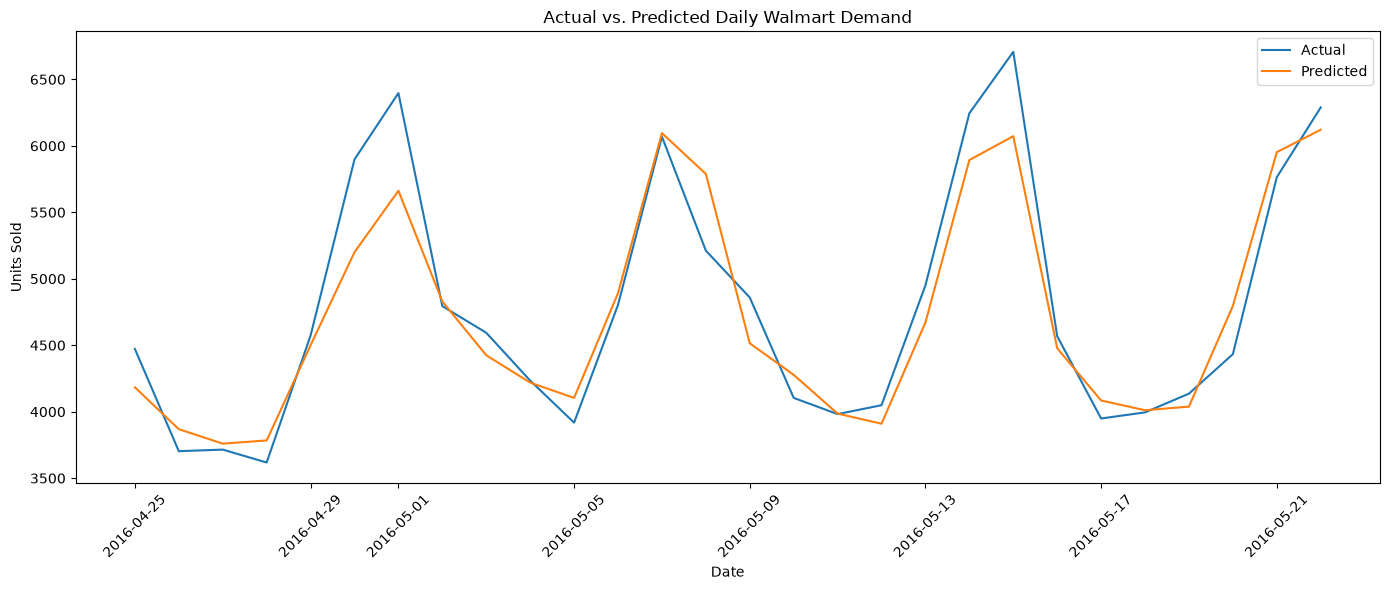

In [16]:
import matplotlib.pyplot as plt

daily_predictions = (
    prediction_results
    .groupby("date")[["units_sold", "predicted_units_sold"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_predictions["date"],
    daily_predictions["units_sold"],
    label="Actual"
)

plt.plot(
    daily_predictions["date"],
    daily_predictions["predicted_units_sold"],
    label="Predicted"
)

plt.title("Actual vs. Predicted Daily Walmart Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Prediction Error Analysis

Prediction errors are calculated to measure the difference between actual and forecasted demand.

Positive errors indicate that actual demand was higher than predicted, while negative errors indicate that the model predicted more demand than actually occurred.

In [17]:
prediction_results["error"] = (
    prediction_results["units_sold"]
    - prediction_results["predicted_units_sold"]
)

prediction_results["absolute_error"] = (
    prediction_results["error"].abs()
)

prediction_results[
    [
        "date",
        "store_id",
        "item_id",
        "units_sold",
        "predicted_units_sold",
        "error",
        "absolute_error"
    ]
].head(20)

,date,store_id,item_id,units_sold,predicted_units_sold,error,absolute_error
1913,2016-04-25,CA_1,FOODS_1_001,2,0.980024,1.019976,1.019976
1914,2016-04-26,CA_1,FOODS_1_001,0,1.023309,-1.023309,1.023309
1915,2016-04-27,CA_1,FOODS_1_001,0,0.906483,-0.906483,0.906483
1916,2016-04-28,CA_1,FOODS_1_001,0,0.879454,-0.879454,0.879454
1917,2016-04-29,CA_1,FOODS_1_001,0,1.005955,-1.005955,1.005955
1918,2016-04-30,CA_1,FOODS_1_001,1,0.873789,0.126211,0.126211
1919,2016-05-01,CA_1,FOODS_1_001,1,1.147839,-0.147839,0.147839
1920,2016-05-02,CA_1,FOODS_1_001,0,1.049243,-1.049243,1.049243
1921,2016-05-03,CA_1,FOODS_1_001,6,0.734104,5.265896,5.265896
1922,2016-05-04,CA_1,FOODS_1_001,1,1.332685,-0.332685,0.332685


### Largest Forecasting Errors

The observations with the largest absolute errors are examined to identify situations where the forecasting model struggled most.

In [18]:
worst_predictions = (
    prediction_results
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

worst_predictions

,date,store_id,item_id,units_sold,predicted_units_sold,error,absolute_error
168862,2016-05-18,CA_1,FOODS_1_088,77,1.191723,75.808277,75.808277
1422752,2016-05-22,CA_1,FOODS_3_120,114,61.920968,52.079032,52.079032
2302000,2016-04-27,CA_1,FOODS_3_573,49,3.911810,45.088190,45.088190
1364514,2016-05-14,CA_1,FOODS_3_090,47,91.953329,-44.953329,44.953329
2288430,2016-05-14,CA_1,FOODS_3_566,66,22.011533,43.988467,43.988467
3109465,2016-05-06,CA_1,HOBBIES_1_169,50,7.639257,42.360743,42.360743
2804734,2016-05-12,CA_1,HOBBIES_1_008,47,7.244191,39.755809,39.755809
3282229,2016-05-21,CA_1,HOBBIES_1_261,47,7.449591,39.550409,39.550409
2288427,2016-05-11,CA_1,FOODS_3_566,53,15.562284,37.437716,37.437716
2288413,2016-04-27,CA_1,FOODS_3_566,41,4.661284,36.338716,36.338716


## Feature Importance

Permutation importance is used to evaluate which features contribute most to the Gradient Boosting model's forecasting performance.

A feature is considered more important when randomly shuffling its values causes a larger decrease in model performance.

In [19]:
from sklearn.inspection import permutation_importance

# Use a sample to keep computation fast
sample_size = min(20000, len(X_test))

X_test_sample = X_test.iloc[:sample_size]
y_test_sample = y_test.iloc[:sample_size]

permutation_results = permutation_importance(
    hgb_model,
    X_test_sample,
    y_test_sample,
    n_repeats=3,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": permutation_results.importances_mean
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(15)

,feature,importance
0,rolling_avg_7,0.273729
1,rolling_avg_28,0.209578
2,lag_1,0.126222
3,day_of_week,0.039215
4,lag_7,0.007331
5,sales_change_7_28,0.004899
6,day_of_month,0.002389
7,sell_price,0.002142
8,is_event,0.001611
9,lag_30,0.001040


### Feature Importance Visualization

The most influential forecasting features are visualized using permutation importance.

Higher importance values indicate that the feature has a greater impact on the Gradient Boosting model's forecasting accuracy.

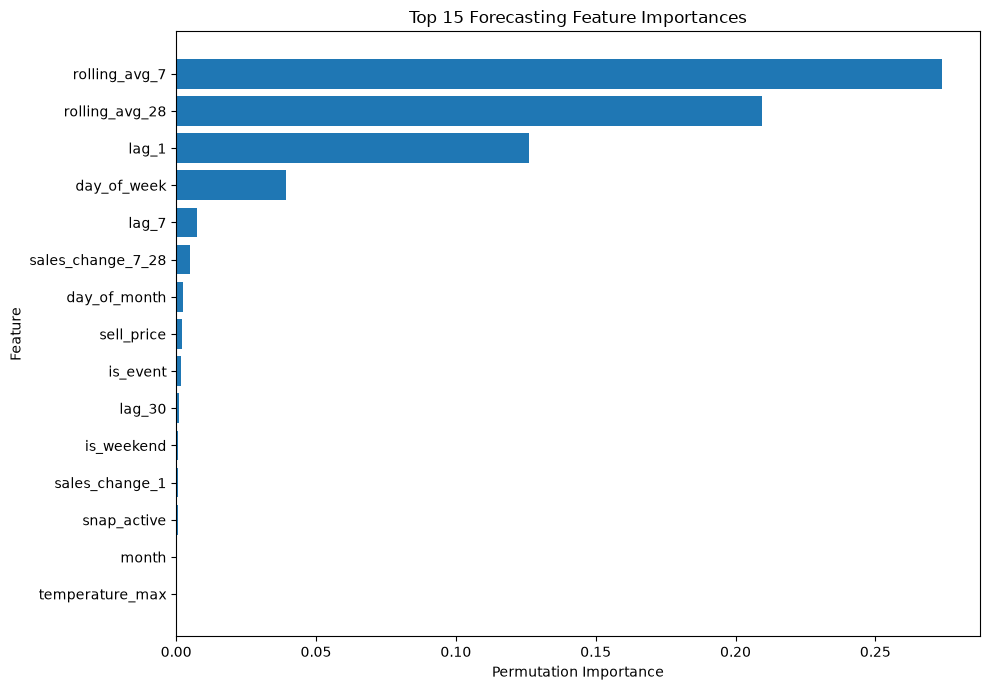

In [20]:
top_features = feature_importance.head(15).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 15 Forecasting Feature Importances")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Save Final Forecasting Model

The best-performing Gradient Boosting model is saved so it can be reused later by the pricing engine, API, and dashboard without retraining the model each time.

In [21]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "gradient_boosting_forecast_model.pkl"

joblib.dump(hgb_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ..\models\gradient_boosting_forecast_model.pkl


## Save Forecast Results

The final test-period forecasts are saved for downstream analysis, pricing simulations, API development, and dashboard visualization.

In [22]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

predictions_path = output_dir / "forecast_predictions.pkl"

prediction_results.to_pickle(predictions_path)

print(f"Predictions saved to: {predictions_path}")
print(f"Rows: {len(prediction_results):,}")
print(f"Columns: {len(prediction_results.columns)}")

Predictions saved to: ..\data\processed\forecast_predictions.pkl
Rows: 85,372
Columns: 7


## Forecasting Results Summary

A time-based 28-day holdout period was used to evaluate Walmart demand forecasting performance.

Three forecasting approaches were compared:

- Baseline Forecast
- Linear Regression
- Gradient Boosting

Gradient Boosting achieved the best overall performance:

- **MAE:** 1.0882
- **RMSE:** 2.0327
- **MAE Improvement vs. Baseline:** 3.60%
- **RMSE Improvement vs. Baseline:** 7.32%

Permutation importance showed that recent historical demand was the strongest predictor of future sales. The most influential features were the 7-day rolling average, 28-day rolling average, and previous-day sales.

The model successfully captured overall demand patterns, although large unexpected demand spikes produced some of the largest forecasting errors.

The trained forecasting model and test-period predictions were saved for downstream use in pricing optimization, API development, and dashboard visualization.